## Notebook for Data Imputation and Internet Index Calculations

Note: The data is already minmax scaled as there was an attempt with PCA before to derive weights for the index. However, PCA was later not used as it did not provide any relevant outputs and the weights were very similar to the current ones and the internet index was the same for PCA derived weights and for current weights. Therefore, for simplicity only the current weights were kept. The PCA notebook is no longer available, as it is not used anymore.

In [12]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

### 1. Impute internet values for missing data

In [27]:
# read data
data = pd.read_json("merged_data.json")

In [ ]:
# Keep only internet features
internet_data = pd.concat([data.iloc[:, :2], data.iloc[:, 7:15]], axis=1)

# Check for missing data
missing_data = internet_data.isna().sum()
print(f"Missing data: \n\n{missing_data}")

# Number of missing data points per row
n_rows = internet_data.isna().sum(axis=1)
# Number of rows with missing data points
n_rows_total = (n_rows > 0).sum()

print(
    f"\nNumber of rows with missing data: {n_rows_total} \nOut of total {len(internet_data)} rows"
)

Missing data: 

Country Name            0
year                    0
v4_prefixes_ris         0
v6_prefixes_ris         0
asns_ris                0
v4_prefixes_stats       0
v6_prefixes_stats       0
asns_stats              0
speed (mgps)          173
bandwidth (kbit/s)    253
dtype: int64

Number of rows with missing data: 384 
Out of total 594 rows


c:\Users\majak\anaconda3\lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\majak\anaconda3\lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


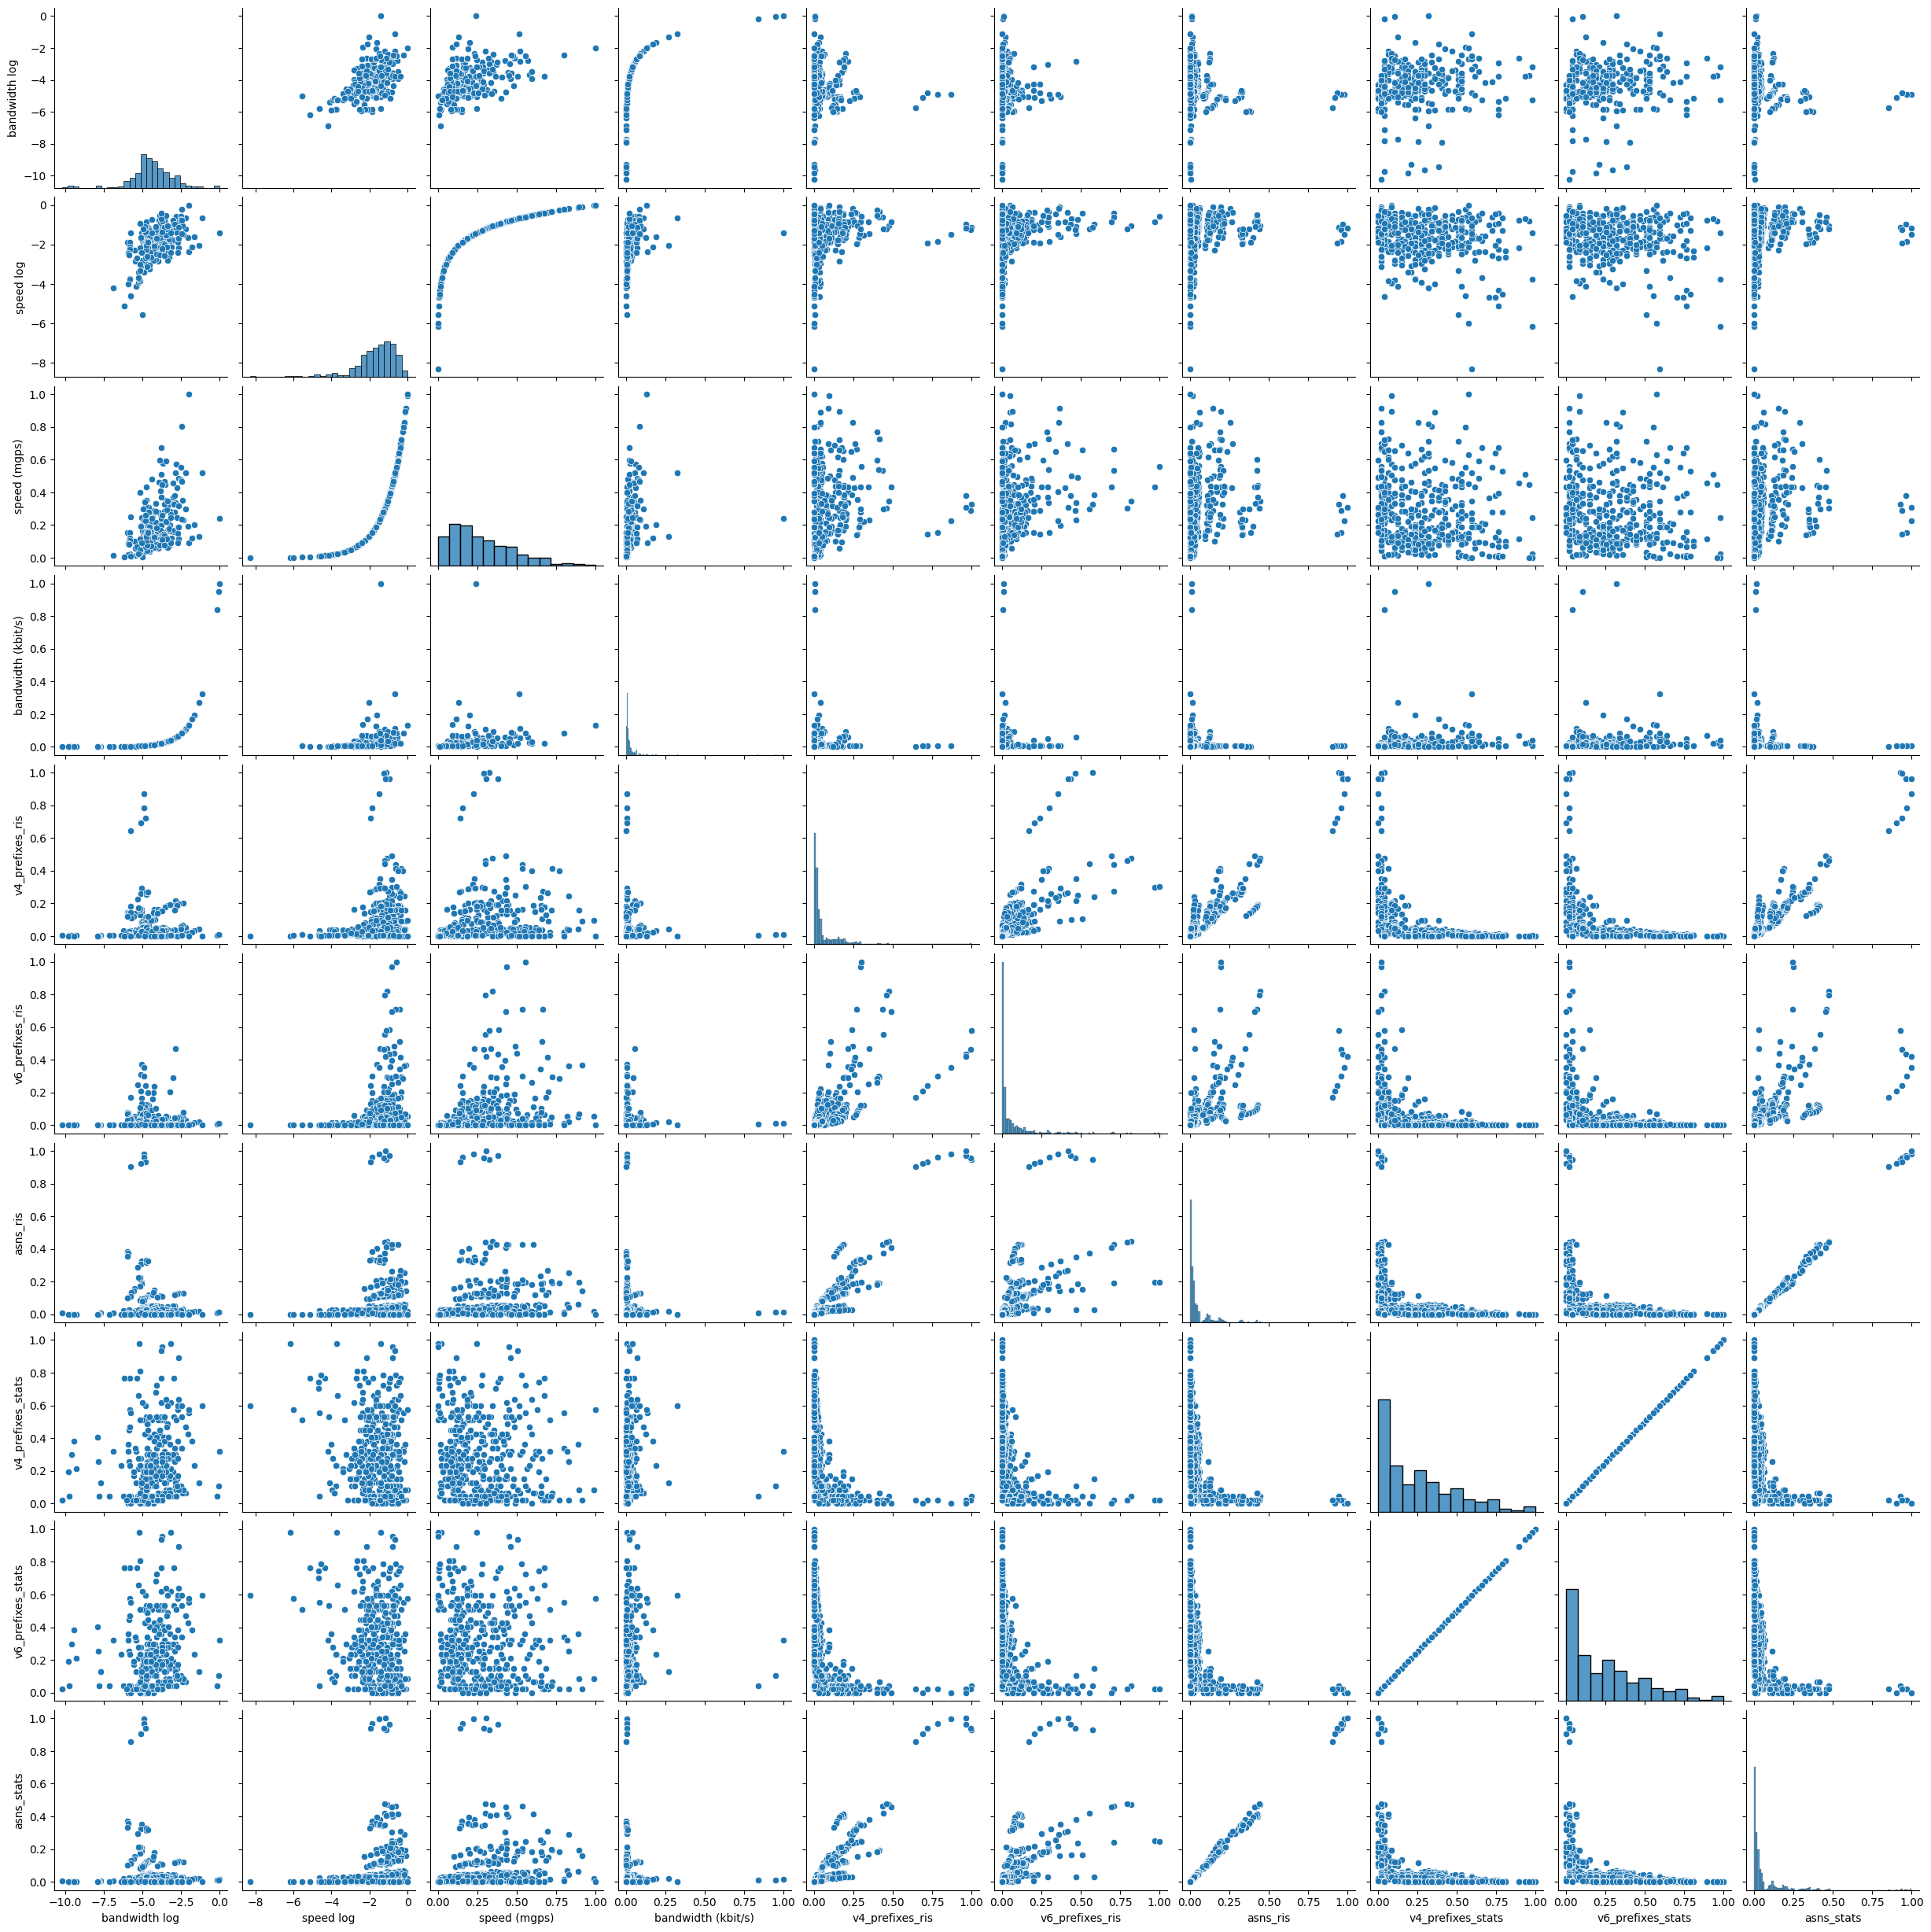

In [31]:
# Take log
data["bandwidth log"] = np.log(data["bandwidth (kbit/s)"])
data["speed log"] = np.log(data["speed (mgps)"])
# visualisation
sns.pairplot(
    data[
        [
            "bandwidth log",
            "speed log",
            "speed (mgps)",
            "bandwidth (kbit/s)",
            "v4_prefixes_ris",
            "v6_prefixes_ris",
            "asns_ris",
            "v4_prefixes_stats",
            "v6_prefixes_stats",
            "asns_stats",
        ]
    ]
)

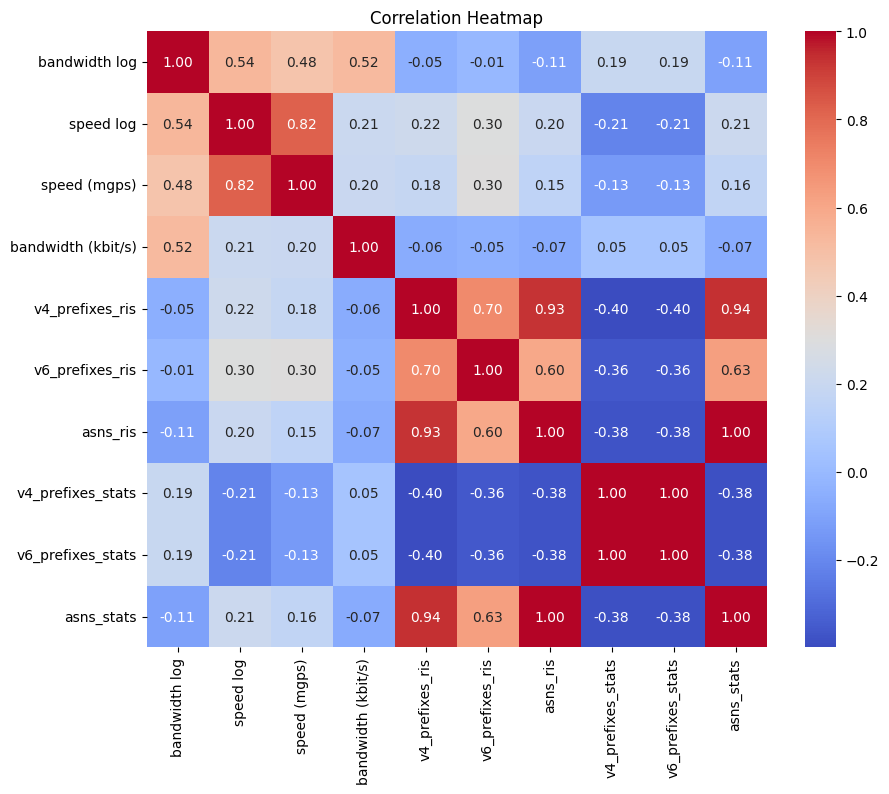

In [32]:
# Correlation
corr_matrix = data[
    [
        "bandwidth log",
        "speed log",
        "speed (mgps)",
        "bandwidth (kbit/s)",
        "v4_prefixes_ris",
        "v6_prefixes_ris",
        "asns_ris",
        "v4_prefixes_stats",
        "v6_prefixes_stats",
        "asns_stats",
    ]
].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

In [33]:
# Extract missing data based on different conditions

# data missing only bandwidth
missing_bandwidth = data[
    pd.isna(data["bandwidth (kbit/s)"]) & pd.notna(data["speed (mgps)"])
]

# data missing only speed
missing_speed = data[
    pd.notna(data["bandwidth (kbit/s)"])
    & pd.isna(data["speed (mgps)"])
    & data["bandwidth (kbit/s)"]
    > 0
]  # filter out negative because of log

# data missing both
missing_both = data[pd.isna(data["bandwidth (kbit/s)"]) & pd.isna(data["speed (mgps)"])]

# data without missing values
non_missing = data[
    pd.notna(data["bandwidth (kbit/s)"]) & pd.notna(data["speed (mgps)"])
]

In [35]:
# impute missing data with linear regression

# Predicting bandwidth
x = non_missing[["speed (mgps)"]]  # must be 2D
y = non_missing["bandwidth log"]

linear_reg_bandwidth = LinearRegression().fit(x, y)
missing_bandwidth["predicted bandwidth log"] = linear_reg_bandwidth.predict(
    missing_bandwidth[["speed (mgps)"]]
)

# Predicting speed
x = non_missing[["bandwidth log"]]  # must be 2D
y = non_missing["speed (mgps)"]

linear_reg_speed = LinearRegression().fit(x, y)
missing_speed["predicted speed"] = linear_reg_speed.predict(
    missing_speed[["bandwidth log"]]
)

# Predicting speed and bandwidth when both are missing
# Speed, predict on v6 ris cause the correlation is 0.3
x = non_missing[["v6_prefixes_ris"]]
y = non_missing["speed (mgps)"]

linear_reg_speed_2 = LinearRegression().fit(x, y)
missing_both["predicted speed 2"] = linear_reg_speed_2.predict(
    missing_both[["v6_prefixes_ris"]]
)

# Bandwidth log, predict on v6 and v4 stats correlation = 0.19
x = non_missing[["v4_prefixes_stats", "v6_prefixes_stats"]]
y = non_missing["bandwidth log"]

linear_reg_bandwidth_2 = LinearRegression().fit(x, y)
missing_both["predicted bandwidth log 2"] = linear_reg_bandwidth_2.predict(
    missing_both[["v4_prefixes_stats", "v6_prefixes_stats"]]
)

C:\Users\majak\AppData\Local\Temp\ipykernel_6568\917623409.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_bandwidth["predicted bandwidth log"] = linear_reg_bandwidth.predict(missing_bandwidth[["speed (mgps)"]])
C:\Users\majak\AppData\Local\Temp\ipykernel_6568\917623409.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_speed["predicted speed"] = linear_reg_speed.predict(missing_speed[["bandwidth log"]])
C:\Users\majak\AppData\Local\Temp\ipykernel_6568\917623409.py:23: SettingWithCopyW

In [36]:
# change log back to normal
missing_bandwidth["predicted bandwidth"] = np.exp(
    missing_bandwidth["predicted bandwidth log"]
)
missing_both["predicted bandwidth 2"] = np.exp(
    missing_both["predicted bandwidth log 2"]
)

# Add predicted column to the original dataset
data.loc[missing_bandwidth.index, "predicted bandwidth"] = missing_bandwidth[
    "predicted bandwidth"
]
data.loc[missing_speed.index, "predicted speed"] = missing_speed["predicted speed"]
data.loc[missing_both.index, "predicted bandwidth 2"] = missing_both[
    "predicted bandwidth 2"
]
data.loc[missing_both.index, "predicted speed 2"] = missing_both["predicted speed 2"]

# create combined columns with imputed data
data["imputed speed"] = data.apply(
    lambda x: x["speed (mgps)"]
    if pd.notna(x["speed (mgps)"])
    else (
        x["predicted speed"]
        if pd.notna(x["predicted speed"])
        else x["predicted speed 2"]
    ),
    axis=1,
)

data["imputed bandwidth"] = data.apply(
    lambda x: x["bandwidth (kbit/s)"]
    if pd.notna(x["bandwidth (kbit/s)"])
    else (
        x["predicted bandwidth"]
        if pd.notna(x["predicted bandwidth"])
        else x["predicted bandwidth 2"]
    ),
    axis=1,
)

C:\Users\majak\AppData\Local\Temp\ipykernel_6568\3327515568.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_bandwidth["predicted bandwidth"] = np.exp(missing_bandwidth["predicted bandwidth log"])
C:\Users\majak\AppData\Local\Temp\ipykernel_6568\3327515568.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_both["predicted bandwidth 2"] = np.exp(missing_both["predicted bandwidth log 2"])


In [38]:
# Keep only relevant columns
data = data.drop(
    columns=[
        "bandwidth log",
        "speed log",
        "predicted bandwidth",
        "predicted speed",
        "predicted bandwidth 2",
        "predicted speed 2",
    ]
)

### 2. Create internet index

Two indices are computed: one with imputed data and one with non-imputed data

In [39]:
# Create index for imputed and non imputed data
# non imputed data
weight = 0.125

weight_dict = {
    "v4_prefixes_ris": weight,
    "v6_prefixes_ris": weight,
    "asns_ris": weight,
    "v4_prefixes_stats": weight,
    "v6_prefixes_stats": weight,
    "asns_stats": weight,
    "speed (mgps)": weight,
    "bandwidth (kbit/s)": weight,
}

data["non_imputed_internet_index"] = data.apply(
    lambda x: sum(x[feature] * weight_dict[feature] for feature in weight_dict), axis=1
)

# imputed data
weight = 0.125

weight_dict = {
    "v4_prefixes_ris": weight,
    "v6_prefixes_ris": weight,
    "asns_ris": weight,
    "v4_prefixes_stats": weight,
    "v6_prefixes_stats": weight,
    "asns_stats": weight,
    "imputed speed": weight,
    "imputed bandwidth": weight,
}

data["imputed_internet_index"] = data.apply(
    lambda x: sum(x[feature] * weight_dict[feature] for feature in weight_dict), axis=1
)

In [41]:
# overwrite existing json
data.to_json("merged_data.json")